# Name: Gogo-Ogute Obediah Etetegwung
# Student ID: A00055446
# Course: Deep Learning Applications
# Project: Cryptocurrency Volatility Prediction Using Deep Learning

## Introduction

Cryptocurrency markets exhibit extreme volatility compared to traditional financial markets.
This project aims to develop a deep learning model capable of predicting Bitcoin price dynamics
using historical market data.

The dataset used consists of historical Bitcoin market data containing price and trading
volume information. A Long Short-Term Memory (LSTM) neural network is implemented to
capture temporal dependencies within the financial time series.

This notebook demonstrates the data preparation, model architecture, and training
process required for cryptocurrency volatility prediction.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
df = pd.read_csv('Bitcoin History.csv')

df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,"Feb 09, 2024","47,545.4","45,293.3","47,710.2","45,254.2",86.85K,4.97%
1,"Feb 08, 2024","45,293.3","44,346.2","45,579.2","44,336.4",66.38K,2.15%
2,"Feb 07, 2024","44,339.8","43,088.4","44,367.9","42,783.5",48.57K,2.91%
3,"Feb 06, 2024","43,087.7","42,697.6","43,375.5","42,566.8",33.32K,0.91%
4,"Feb 05, 2024","42,697.2","42,581.4","43,532.2","42,272.5",39.26K,0.27%


The dataset contains historical Bitcoin price information including opening price,
closing price, daily high and low prices, trading volume, and percentage change.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4955 entries, 0 to 4954
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      4955 non-null   object
 1   Price     4955 non-null   object
 2   Open      4955 non-null   object
 3   High      4955 non-null   object
 4   Low       4955 non-null   object
 5   Vol.      4955 non-null   object
 6   Change %  4955 non-null   object
dtypes: object(7)
memory usage: 271.1+ KB


In [ ]:
df['Price'] = df['Price'].str.replace(',', '').astype(float)
df['Open'] = df['Open'].str.replace(',', '').astype(float)
df['High'] = df['High'].str.replace(',', '').astype(float)
df['Low'] = df['Low'].str.replace(',', '').astype(float)

df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,"Feb 09, 2024",47545.4,45293.3,47710.2,45254.2,86.85K,4.97%
1,"Feb 08, 2024",45293.3,44346.2,45579.2,44336.4,66.38K,2.15%
2,"Feb 07, 2024",44339.8,43088.4,44367.9,42783.5,48.57K,2.91%
3,"Feb 06, 2024",43087.7,42697.6,43375.5,42566.8,33.32K,0.91%
4,"Feb 05, 2024",42697.2,42581.4,43532.2,42272.5,39.26K,0.27%


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

In [ ]:
df.isnull().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,0
Change %,0


In [ ]:
df = df.fillna(method='ffill')

/tmp/ipykernel_3658/569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


Missing values are handled using forward-fill interpolation to maintain temporal consistency.

In [ ]:
data = df[['Open','High','Low','Price']]

These features capture the market structure and price fluctuations of Bitcoin and
are commonly used in financial forecasting models.

In [ ]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

Feature scaling is applied using MinMax normalization to improve neural network training stability.

In [ ]:
def create_sequences(data, window=30):
    X = []
    y = []

    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window,3])

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

A 30-day rolling window is used to convert the dataset into sequences suitable
for LSTM training.

In [ ]:
X.shape

(4925, 30, 4)

In [ ]:
train_size = int(len(X)*0.7)
val_size = int(len(X)*0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

In [ ]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(30,4)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,753 (198.25 KB)

 Trainable params: 50,753 (198.25 KB)

 Non-trainable params: 0 (0.00 B)

The LSTM architecture is chosen due to its ability to capture long-term dependencies
in time-series data.

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 1.5353e-04 - val_loss: 0.0060
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 6.7913e-05 - val_loss: 0.0040
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 7.8791e-05 - val_loss: 0.0044
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 6.5976e-05 - val_loss: 0.0064
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 5.7594e-05 - val_loss: 0.0102
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 5.8290e-05 - val_loss: 0.0029
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 5.8065e-05 - val_loss: 0.0045
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 5.0389e-05 - val_loss: 0.0067
Epoch 9/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 4.7916e-05 - val_loss: 0.0087
Epoch 10/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 5.2817e-05 - val_loss: 0.0066
Epoch 11/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 4.9104e-05 - val_loss: 0.01

In [ ]:
model.evaluate(X_test,y_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0022


0.0021581281907856464

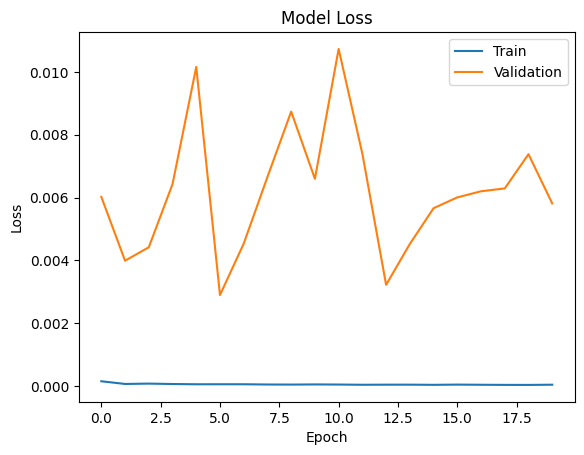

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()

## Conclusion

The LSTM model successfully learns temporal patterns within the Bitcoin
price time series. The training and validation losses indicate that the
model can capture underlying market dynamics.

Future improvements will include the integration of sentiment data and
blockchain metrics to build a multimodal deep learning framework for
cryptocurrency volatility prediction.

In [ ]:
# Re-split your dataset properly
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Retrain
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
df.head()

124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 7.2703e-04
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


,Date,Price,Open,High,Low,Vol.,Change %
4954,2010-07-18,0.1,0.0,0.1,0.1,0.08K,0.00%
4953,2010-07-19,0.1,0.1,0.1,0.1,0.57K,0.00%
4952,2010-07-20,0.1,0.1,0.1,0.1,0.26K,0.00%
4951,2010-07-21,0.1,0.1,0.1,0.1,0.58K,0.00%
4950,2010-07-22,0.1,0.1,0.1,0.1,2.16K,0.00%


In [ ]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Save model
model.save("model.h5")

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 5.8564e-04
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 5.9212e-04
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 5.5307e-04
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 5.0092e-04
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 4.9509e-04
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 5.8766e-04
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 4.9072e-04
Epoch 8/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 5.4526e-04
Epoch 9/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 5.2576e-04
Epoch 10/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 4.7019e-04


In [ ]:
from google.colab import files
files.download("model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
y_pred = model.predict(X_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)


Mean Absolute Error (MAE): 0.007566169770952358
Root Mean Squared Error (RMSE): 0.014391402520570213


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.00020711246650907466
R2 Score: 0.9954972638578047


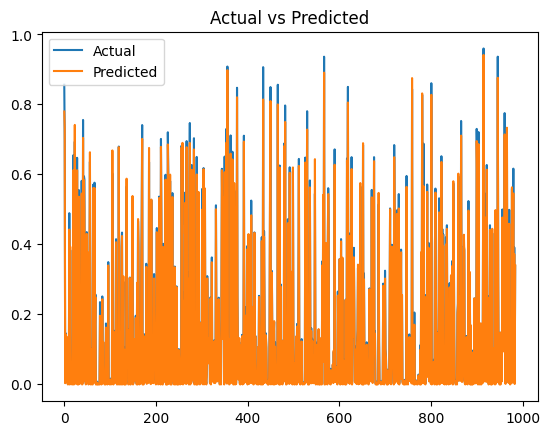

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
import gradio as gr
import numpy as np
import joblib

# Load model and scaler
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

# ---------- CORE FUNCTIONS ----------

def validate_and_predict(input_text):
    try:
        rows = input_text.strip().split("\n")

        # Validation 1: number of rows
        if len(rows) != 30:
            return "❌ Error: Please enter exactly 30 rows (one per day)."

        data = []
        for i, row in enumerate(rows):
            values = row.split(",")

            # Validation 2: number of features
            if len(values) != 4:
                return f"❌ Error on line {i+1}: Must contain 4 values (Open, High, Low, Price)."

            try:
                values = [float(x) for x in values]
            except:
                return f"❌ Error on line {i+1}: All values must be numeric."

            data.append(values)

        data = np.array(data)

        # Scale
        scaled = scaler.transform(data)

        # Reshape for LSTM
        X_input = scaled.reshape(1, 30, 4)

        # Predict
        prediction_scaled = model.predict(X_input)

        # Inverse transform
        dummy = np.zeros((1, 4))
        dummy[0, 3] = prediction_scaled[0, 0]

        predicted_price = scaler.inverse_transform(dummy)[0, 3]

        return f"✅ Predicted Bitcoin Price: {predicted_price:.2f}"

    except Exception as e:
        return f"❌ Unexpected error: {str(e)}"


# ---------- SAMPLE DATA ----------

def load_sample_data():
    sample = "\n".join([
        "30000,30500,29500,30200",
        "30200,31000,30000,30800",
        "30800,31500,30500,31200"
    ] * 10)  # 30 rows total
    return sample


# ---------- TEST FUNCTION ----------

def run_test_prediction():
    try:
        # Simulated sample (same structure as training)
        sample = np.array([[30000,30500,29500,30200]] * 30)
        scaled = scaler.transform(sample)
        X_input = scaled.reshape(1, 30, 4)

        prediction_scaled = model.predict(X_input)

        dummy = np.zeros((1, 4))
        dummy[0, 3] = prediction_scaled[0, 0]

        predicted_price = scaler.inverse_transform(dummy)[0, 3]

        return f"🧪 Test Prediction Successful → {predicted_price:.2f}"

    except Exception as e:
        return f"❌ Test failed: {str(e)}"


# ---------- UI DESIGN ----------

with gr.Blocks() as app:
    gr.Markdown("# 📈 Bitcoin Price Predictor (LSTM)")
    gr.Markdown(
        "Enter **30 days of data** (Open, High, Low, Price).\n"
        "Or use sample data to test the model instantly."
    )

    input_box = gr.Textbox(
        lines=15,
        placeholder="Example:\n30000,30500,29500,30200\n...",
        label="Input Data (30 rows required)"
    )

    output_box = gr.Textbox(label="Prediction Output")

    with gr.Row():
        predict_btn = gr.Button("🔮 Predict")
        sample_btn = gr.Button("📥 Load Sample Data")
        test_btn = gr.Button("🧪 Run Test")

    # Button actions
    predict_btn.click(fn=validate_and_predict, inputs=input_box, outputs=output_box)
    sample_btn.click(fn=load_sample_data, outputs=input_box)
    test_btn.click(fn=run_test_prediction, outputs=output_box)


# Launch app
app.launch()

NameError: name 'load_model' is not defined

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def validate_and_predict(input_text):
    ...
    predicted_price = scaler.inverse_transform(dummy)[0, 3]

    # Create simple plot
    fig = plt.figure()
    plt.plot(data[:, 3], label="Input Prices")
    plt.axhline(predicted_price, linestyle='--', label="Predicted")
    plt.legend()
    plt.title("Prediction Visualization")

    return f"Predicted Price: {predicted_price:.2f}", fig

In [ ]:
outputs=[gr.Textbox(label="Prediction"), gr.Plot()]
app.launch()

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://97f1e0ba96ac42ce71.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>